In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


df = pd.read_csv("../data/hcvdata.csv")
df = df.drop(columns=["Unnamed: 0"])

for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

df["Sex"] = df["Sex"].map({"m": 1, "f": 0})

X = df.drop(columns=["Category"])
y = df["Category"]
categories = y.unique()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
print(X_scaled)

[[-1.53361617  0.79454373 -0.54073873 ...  0.49707027 -0.50228619
  -0.56441905]
 [-1.53361617  0.79454373 -0.54073873 ... -0.14658961 -0.43820313
   0.82605409]
 [-1.53361617  0.79454373  0.91475496 ...  0.09478284 -0.11595686
   1.34516406]
 ...
 [ 1.65143725 -1.25858397 -2.18683279 ... -0.29342452  0.45163601
   1.84573439]
 [-0.1401553  -1.25858397 -1.49374055 ... -0.58910578  0.19164186
  -0.19362621]
 [ 1.15377266 -1.25858397 -0.97392137 ... -0.28739021 -0.1013093
  -0.74981546]]


In [24]:
class CovPCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.eigenvalues = None
        self.eigenvectors = None
        self.explained_variance_ratio = None

    def fit_transform(self, X):
        if self.n_components is None:
            self.n_components = X.shape[1]

        cov_matrix = np.cov(X, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        eigenvalues = np.real(eigenvalues)
        eigenvectors = np.real(eigenvectors)

        idx = eigenvalues.argsort()[::-1]
        self.eigenvalues = eigenvalues[idx]
        self.eigenvectors = eigenvectors[:, idx]

        total_variance = np.sum(self.eigenvalues)
        self.explained_variance_ratio = self.eigenvalues[:self.n_components] / total_variance

        W = self.eigenvectors[:, :self.n_components]
        X_transformed = X.dot(W)

        return X_transformed


custom_pca_2d = CovPCA(n_components=2)
custom_pca_3d = CovPCA(n_components=3)

X_custom_2d = custom_pca_2d.fit_transform(X_scaled)
X_custom_3d = custom_pca_3d.fit_transform(X_scaled)

explained_var_2d = np.sum(custom_pca_2d.explained_variance_ratio)
explained_var_3d = np.sum(custom_pca_3d.explained_variance_ratio)

loss_2d = 1 - explained_var_2d
loss_3d = 1 - explained_var_3d

print(f"Объясненная дисперсия (2D): {explained_var_2d * 100:.2f}%")
print(f"Потери при 2D-проекции: {loss_2d * 100:.2f}%\n")
print(f"Объясненная дисперсия (3D): {explained_var_3d * 100:.2f}%")
print(f"Потери при 3D-проекции: {loss_3d * 100:.2f}%")

Объясненная дисперсия (2D): 36.34%
Потери при 2D-проекции: 63.66%

Объясненная дисперсия (3D): 48.16%
Потери при 3D-проекции: 51.84%


In [25]:
pca_2d = PCA(n_components=2)
X_sklearn_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_sklearn_3d = pca_3d.fit_transform(X_scaled)

sklearn_explained_var_2d = np.sum(pca_2d.explained_variance_ratio_)
sklearn_explained_var_3d = np.sum(pca_3d.explained_variance_ratio_)

sklearn_loss_2d = 1 - sklearn_explained_var_2d
sklearn_loss_3d = 1 - sklearn_explained_var_3d

print(f"Объясненная дисперсия (2D): {sklearn_explained_var_2d * 100:.2f}%")
print(f"Потери при 2D-проекции (sklearn): {sklearn_loss_2d * 100:.2f}%")
print(f"Объясненная дисперсия (3D): {sklearn_explained_var_3d * 100:.2f}%")
print(f"Потери при 3D-проекции (sklearn): {sklearn_loss_3d * 100:.2f}%")

Объясненная дисперсия (2D): 36.34%
Потери при 2D-проекции (sklearn): 63.66%
Объясненная дисперсия (3D): 48.16%
Потери при 3D-проекции (sklearn): 51.84%


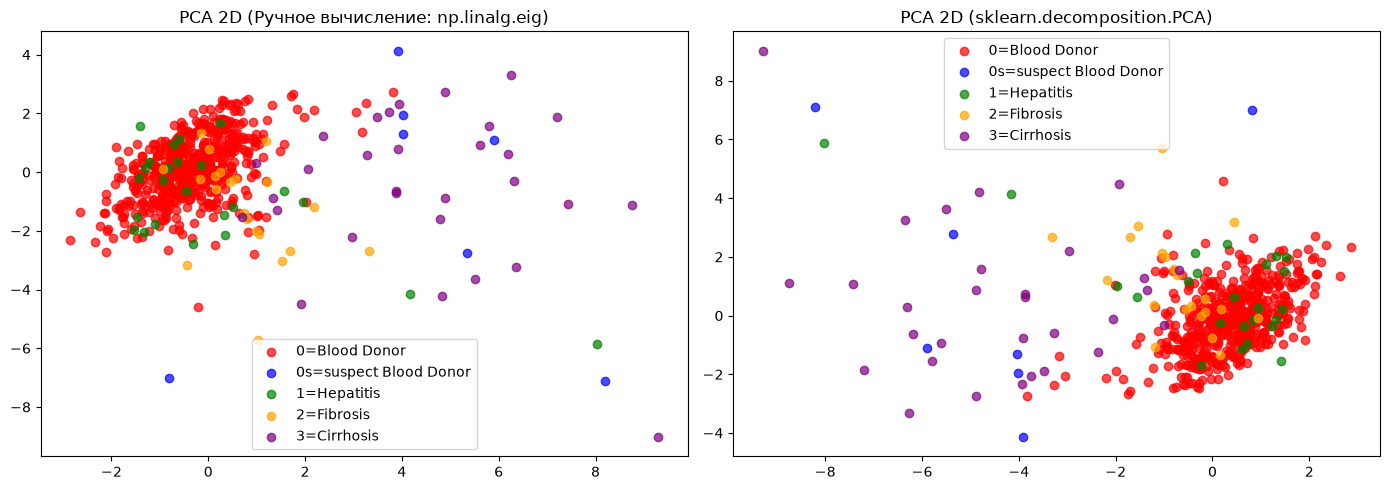

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, cat in enumerate(categories):
    idx_cat = (y == cat)
    axes[0].scatter(X_custom_2d[idx_cat, 0], X_custom_2d[idx_cat, 1],
                    c=colors[i % len(colors)], label=cat, alpha=0.7)

    axes[1].scatter(X_sklearn_2d[idx_cat, 0], X_sklearn_2d[idx_cat, 1],
                    c=colors[i % len(colors)], label=cat, alpha=0.7)
    

axes[0].set_title('PCA 2D (Ручное вычисление: np.linalg.eig)')
axes[1].set_title('PCA 2D (sklearn.decomposition.PCA)')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

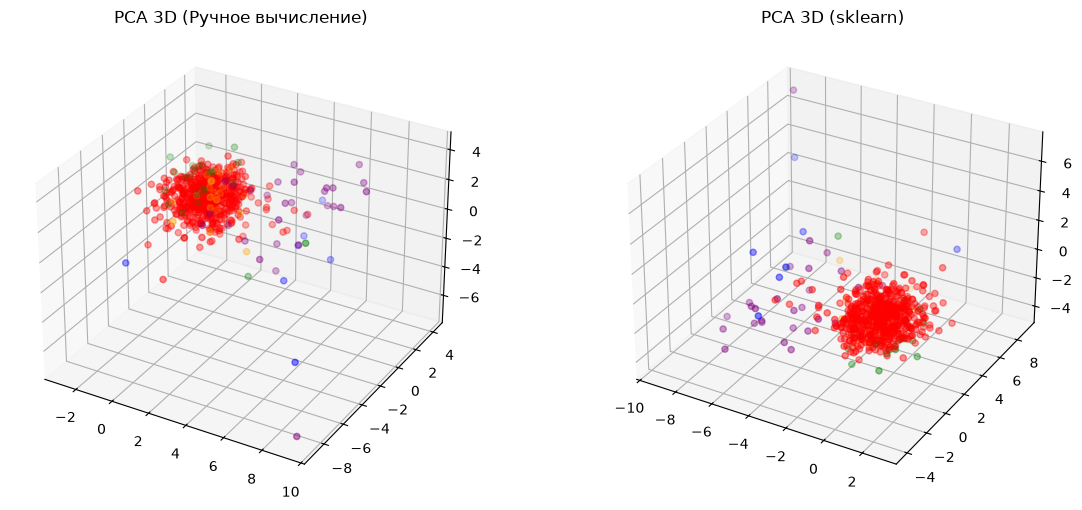

In [22]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

for i, cat in enumerate(categories):
    idx_cat = (y == cat)
    ax1.scatter(X_custom_3d[idx_cat, 0], X_custom_3d[idx_cat, 1], X_custom_3d[idx_cat, 2], 
                c=colors[i % len(colors)], label=cat, alpha=0.7)
    ax2.scatter(X_sklearn_3d[idx_cat, 0], X_sklearn_3d[idx_cat, 1], X_sklearn_3d[idx_cat, 2], 
                c=colors[i % len(colors)], label=cat, alpha=0.7)

ax1.set_title('PCA 3D (Ручное вычисление)')
ax2.set_title('PCA 3D (sklearn)')
plt.show()